In [2]:
import pandas as pd
file_path = 'UST Data Sample (July - Sept 2024).xlsx'
df = pd.read_excel(file_path)

In [3]:
df.columns

Index(['let me tak', 'Id', 'Client', 'RFQStatus', 'InstrumentSubGroup',
       'Market Traded Vol (USD)', 'Our Traded Vol', 'TiedWonVol',
       'Num of Dealers', 'Trader', 'Sales', 'Covered Vol', 'ActionStr', 'Tier',
       'InstrumentCode', 'InstrumentDescription', 'AssetClass', 'Market',
       'LegNo', 'Maturity Date', 'RFQNumberOfQuotes', 'Buy/Sell',
       'Best Bid Price', 'Mid Price', 'Best Ask Price', 'Deal Value',
       'AwayFromMid', 'TickIdentifier', 'Deal Spread', 'Cover', 'CoverPnL',
       'SettlementDays', 'SettlementDate', 'SettlementStops', 'RFQ CreateTime',
       'RFQ ClosedTime', 'AnAutoReplyRFQs', 'First Response Time (Sec)',
       'TradeSizeBucket', 'Sector', 'MaturityBucket'],
      dtype='object')

# Response Time

In [10]:
# response time analysis
df.groupby("Trader")['First Response Time (Sec)'].agg(['mean', 'median', 'min', 'max']).sort_values(by='mean', ascending=False)

,mean,median,min,max
Trader,,,,
Trader9,5.492620,0.00,0.0,55.55
Trader7,2.505709,0.03,0.0,51.52
Trader4,1.895537,0.03,0.0,58.37
Trader1,1.425792,0.03,0.0,59.67
Trader5,0.767108,0.03,0.0,57.55
Trader3,0.343724,0.03,0.0,109.09
Trader6,0.286412,0.03,0.0,44.00
Trader2,0.079023,0.03,0.0,37.04
Trader8,0.000000,0.00,0.0,0.00


In [19]:
# analysis with response time by Trader
df.groupby("Trader")['First Response Time (Sec)'].agg(['mean', 'median', 'min', 'max']).sort_values(by='mean', ascending=False)

,mean,median,min,max
Trader,,,,
Trader9,5.492620,0.00,0.0,55.55
Trader7,2.505709,0.03,0.0,51.52
Trader4,1.895537,0.03,0.0,58.37
Trader1,1.425792,0.03,0.0,59.67
Trader5,0.767108,0.03,0.0,57.55
Trader3,0.343724,0.03,0.0,109.09
Trader6,0.286412,0.03,0.0,44.00
Trader2,0.079023,0.03,0.0,37.04
Trader8,0.000000,0.00,0.0,0.00


In [32]:
#RFQ CreateTime and RFQ ClosedTime
df['meanRFQ']=(df['RFQ ClosedTime'] - df['RFQ CreateTime']).dt.total_seconds()
df.groupby("Trader")['meanRFQ'].agg(['mean','median',"max",'min'],).sort_values(by=['mean','median'], ascending=False)

,mean,median,max,min
Trader,,,,
Trader1,14.988209,0.0,180.0,0.0
Trader7,13.518822,0.0,180.0,0.0
Trader4,12.023083,0.0,120.0,0.0
Trader9,10.947368,0.0,180.0,0.0
Trader3,9.475834,0.0,180.0,0.0
Trader6,8.844563,0.0,180.0,0.0
Trader5,8.411523,0.0,180.0,0.0
Trader2,7.325998,0.0,180.0,0.0
Trader8,0.000000,0.0,0.0,0.0


In [39]:
# by client
df.groupby("Client")['First Response Time (Sec)'].agg(['mean', 'median', 'min', 'max']).sort_values(by='mean', ascending=False)

,mean,median,min,max
Client,,,,
Client636,28.455,27.865,0.00,58.09
Client901,22.750,22.750,22.75,22.75
Client858,19.060,19.060,19.06,19.06
Client757,13.920,13.920,13.92,13.92
Client564,12.750,12.750,12.54,12.96
...,...,...,...,...
Client713,0.000,0.000,0.00,0.00
Client594,0.000,0.000,0.00,0.00
Client911,0.000,0.000,0.00,0.00


In [40]:
df.groupby("Client")['meanRFQ'].agg(['mean','median',"max",'min'],).sort_values(by=['mean','median'], ascending=False)

,mean,median,max,min
Client,,,,
Client798,120.0,120.0,120.0,120.0
Client901,120.0,120.0,120.0,120.0
Client523,100.0,120.0,120.0,60.0
Client865,90.0,90.0,120.0,60.0
Client879,90.0,90.0,120.0,60.0
...,...,...,...,...
Client922,0.0,0.0,0.0,0.0
Client923,0.0,0.0,0.0,0.0
Client925,0.0,0.0,0.0,0.0


# InstrumentSubGroup

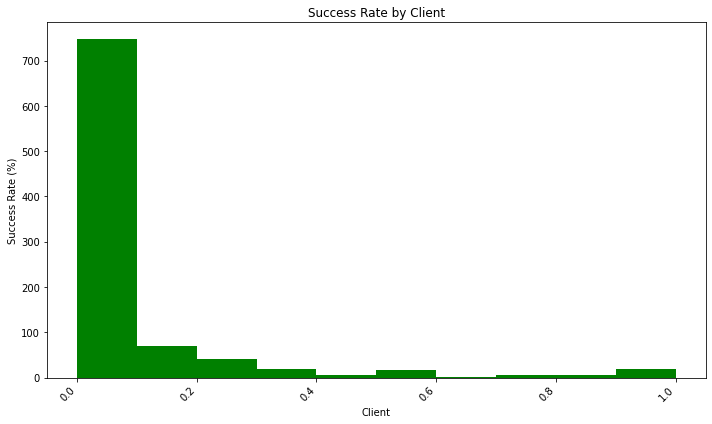

In [64]:
# Further analysis with Instrument SubGroup
import matplotlib.pyplot as plt
# 1. Success Rate per Client
df['Success'] = df['RFQStatus'].apply(lambda x: 1 if x == 'Done' else 0)

# 1. Success Rate per Client
df['Success'] = df['RFQStatus'].apply(lambda x: 1 if x == 'Done' else 0)
client_success_rate = df.groupby('Client')['Success'].mean()

plt.figure(figsize=(10, 6))
plt.hist(client_success_rate, color='green')
plt.title('Success Rate by Client')
plt.ylabel('Success Rate (%)')
plt.xlabel('Client')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




Index(['OFFTHERUN', 'OFFTHERUN,DOUBLEOLDS', 'OFFTHERUN,OLDBONDS', 'ONTHERUN',
       'UNKNOWN'],
      dtype='object', name='InstrumentSubGroup')


<Figure size 864x504 with 0 Axes>

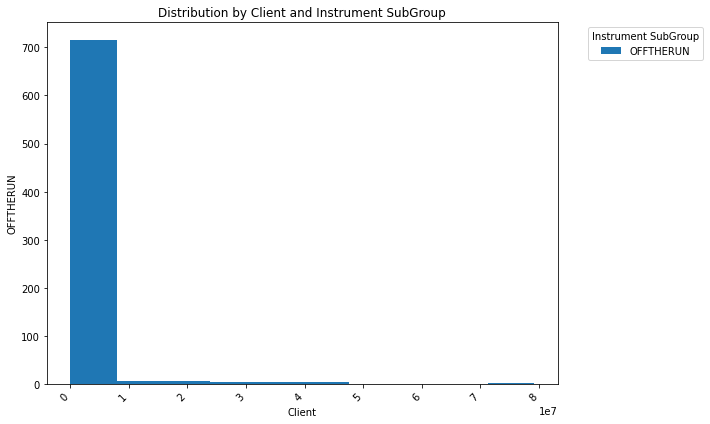

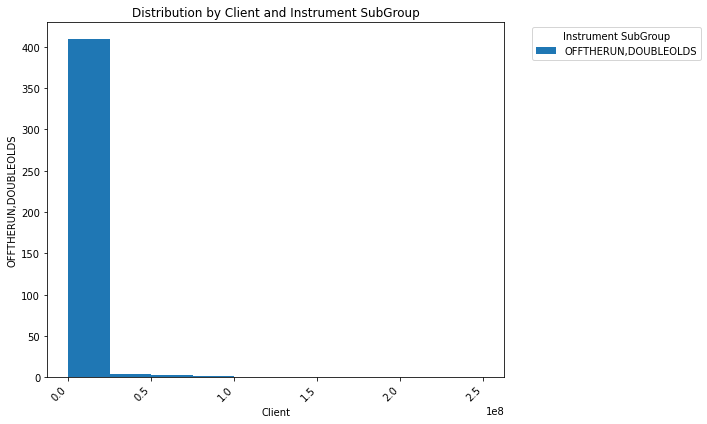

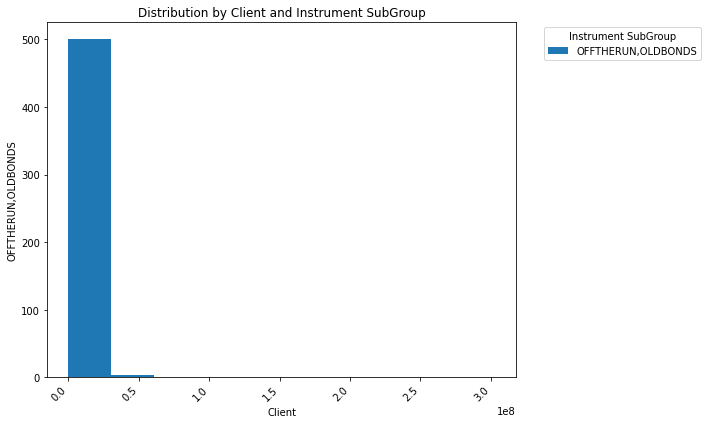

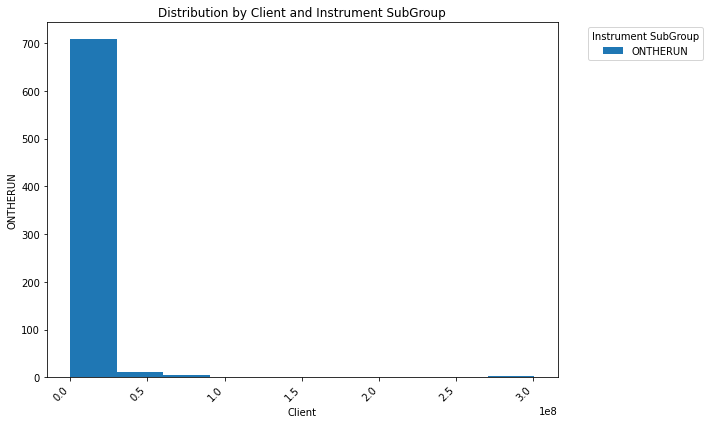

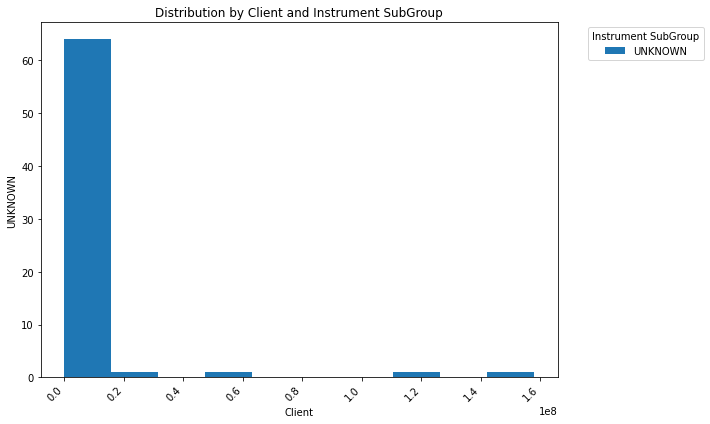

In [65]:
# 2. Average Trade Volume by Instrument SubGroup
client_instrument_avg_volume = df.groupby(['Client', 'InstrumentSubGroup'])['Our Traded Vol'].mean().unstack()

print(client_instrument_avg_volume.columns)
# Plotting average traded volume by client and instrument subgroup
plt.figure(figsize=(12, 7))
for column in client_instrument_avg_volume.columns:
    plt.figure(figsize=(10, 6))
    plt.hist(client_instrument_avg_volume[column], label=column)
    plt.title('Distribution by Client and Instrument SubGroup')
    plt.ylabel(client_instrument_avg_volume[column].name)
    plt.xlabel('Client')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Instrument SubGroup', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


TradeSizeBucket             1-5M      10-25M      25-50M       5-10M  \
InstrumentSubGroup                                                     
OFFTHERUN              529387700  1474663800  1728240900   279347800   
OFFTHERUN,DOUBLEOLDS   123859900   180759000   307903000    65226000   
OFFTHERUN,OLDBONDS     311086700   695203400   763106700   304722000   
ONTHERUN              2205412800  5152965300  4499041300  1773378300   
UNKNOWN                  3100000   181322500   284085000    12000000   

TradeSizeBucket              50+M    500K-1M  
InstrumentSubGroup                            
OFFTHERUN             21126467300   74464100  
OFFTHERUN,DOUBLEOLDS   3696539000   10734000  
OFFTHERUN,OLDBONDS     6212900800   50318000  
ONTHERUN              32435289100  199124600  
UNKNOWN                2149000000          0  


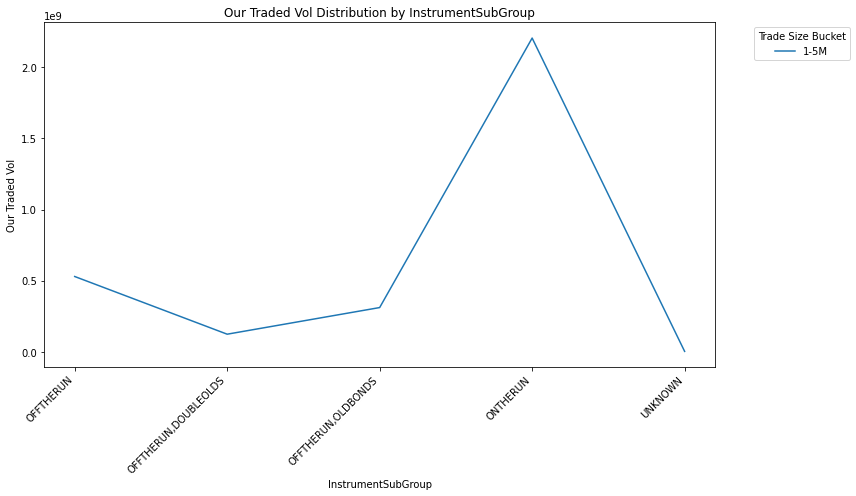

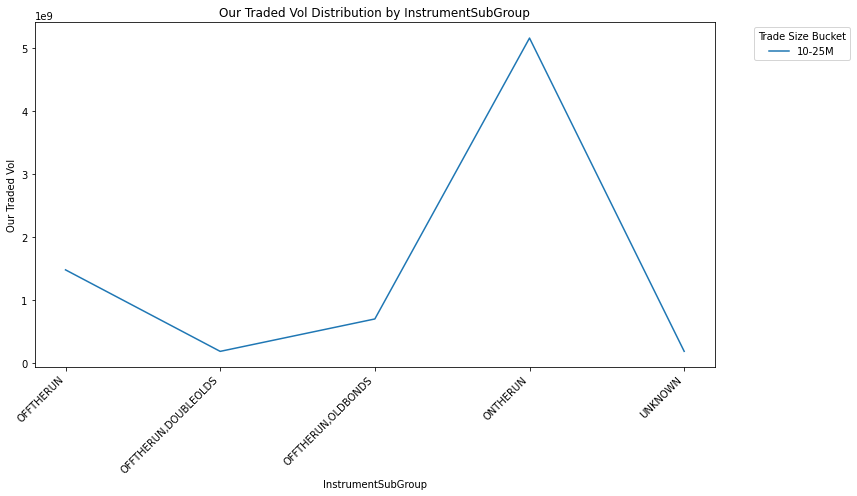

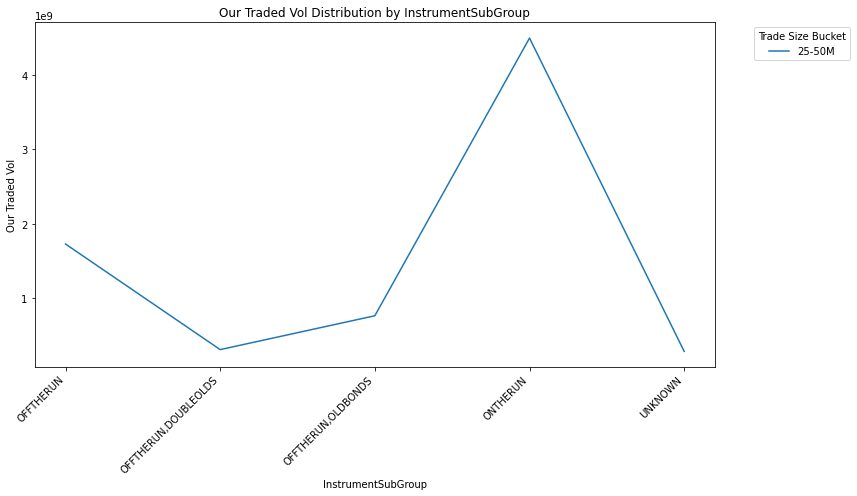

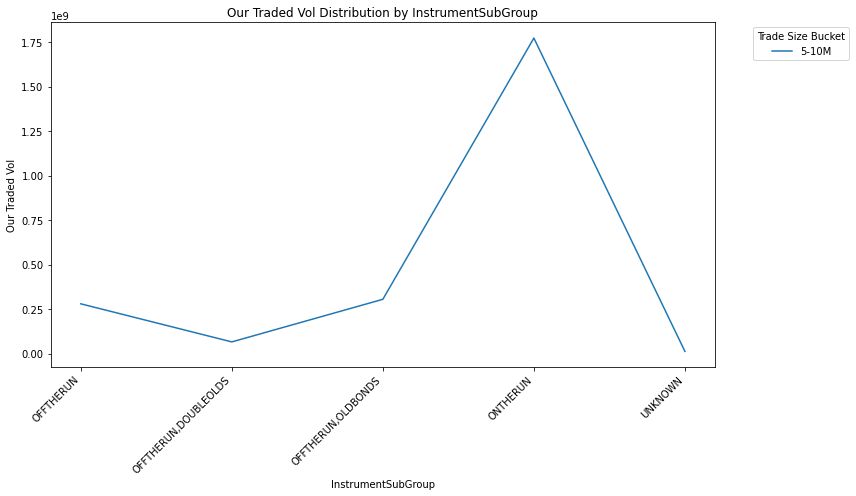

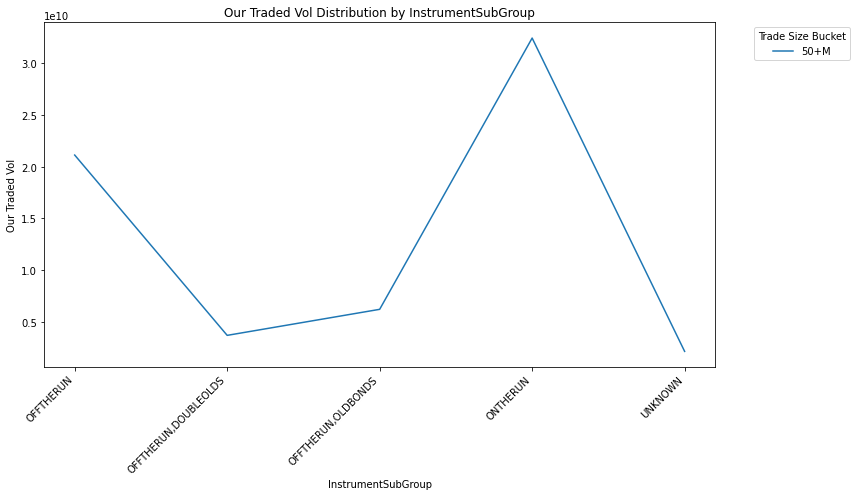

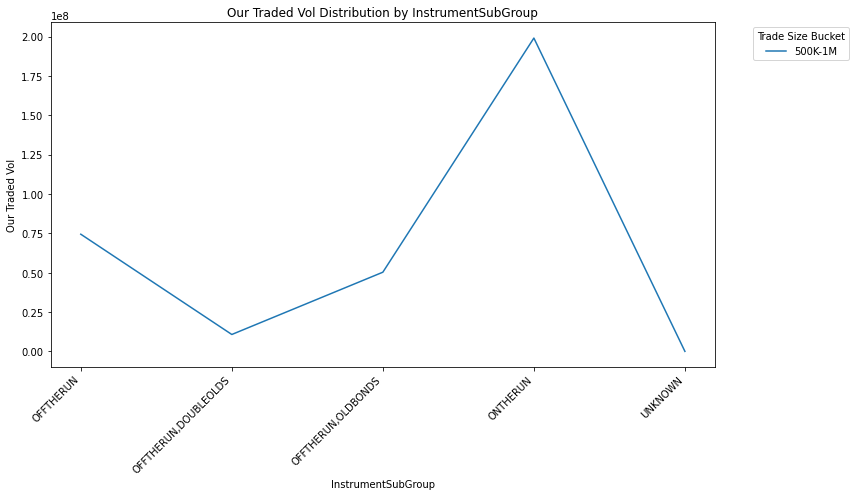

In [86]:
# 3. Trade Size Buckets by Client and Instrument SubGroup
trade_size_distribution = df.groupby(['InstrumentSubGroup', 'TradeSizeBucket'])['Our Traded Vol'].sum().unstack()
print(trade_size_distribution)
# Plotting trade size distribution by client and instrument subgroup
for column in trade_size_distribution.columns:
    plt.figure(figsize=(12, 7))
    plt.plot(trade_size_distribution.index, trade_size_distribution[column], label=column)
    plt.title('Our Traded Vol Distribution by InstrumentSubGroup')
    plt.ylabel("Our Traded Vol")
    plt.xlabel('InstrumentSubGroup')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Trade Size Bucket', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

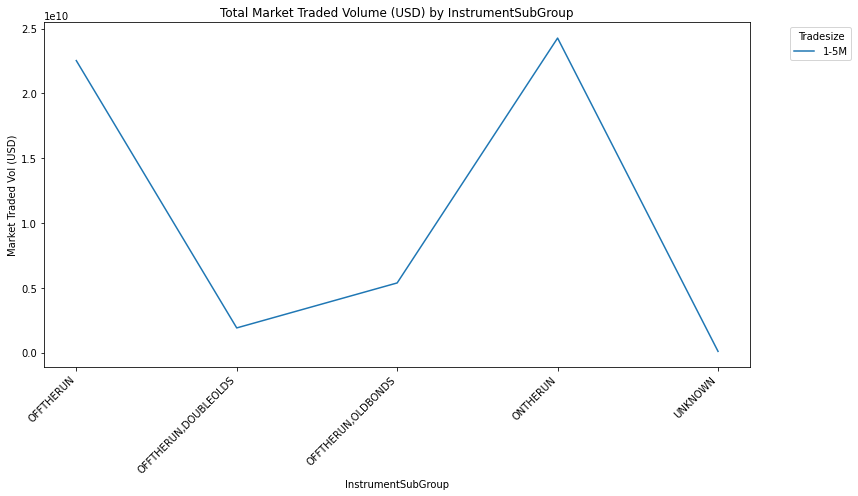

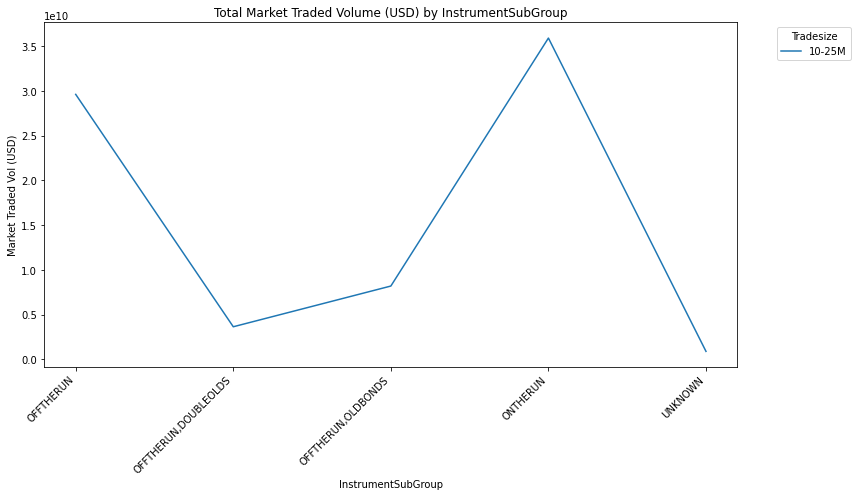

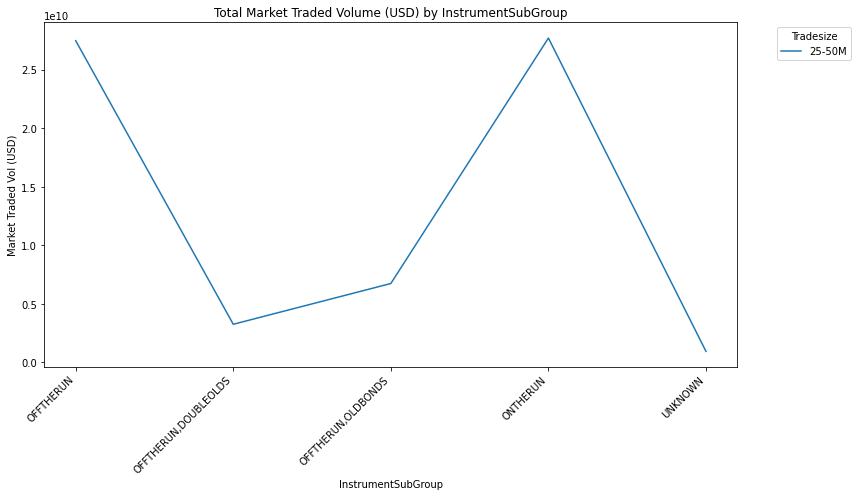

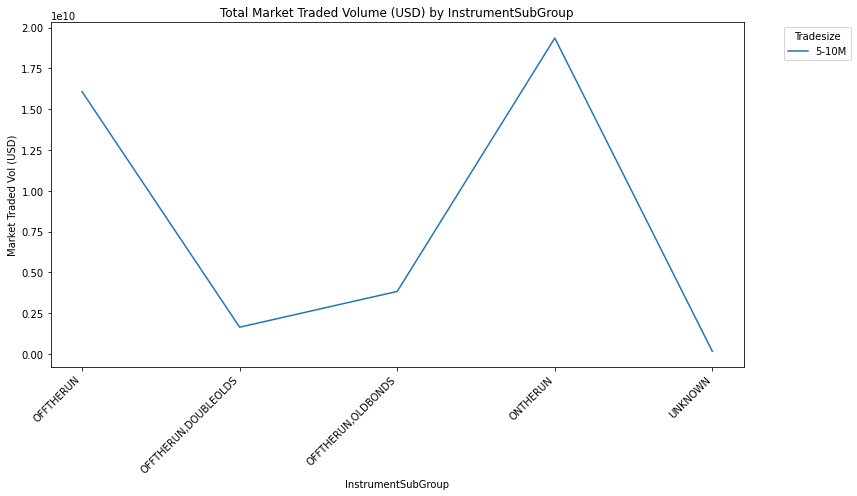

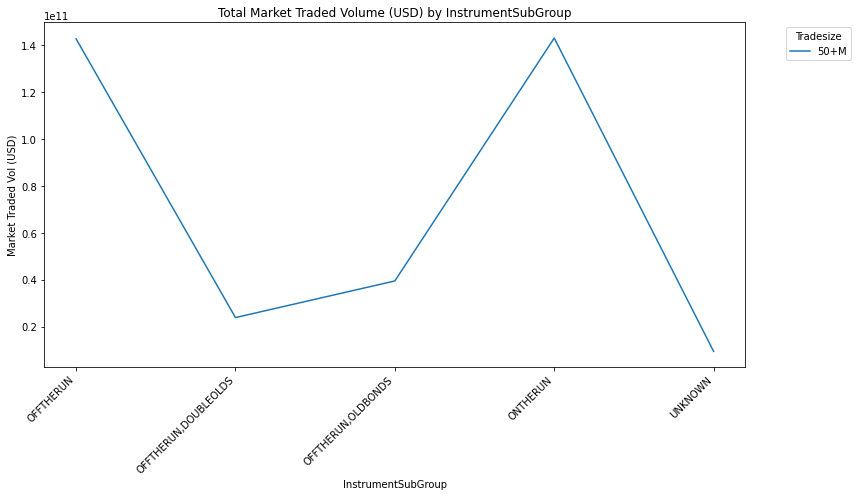

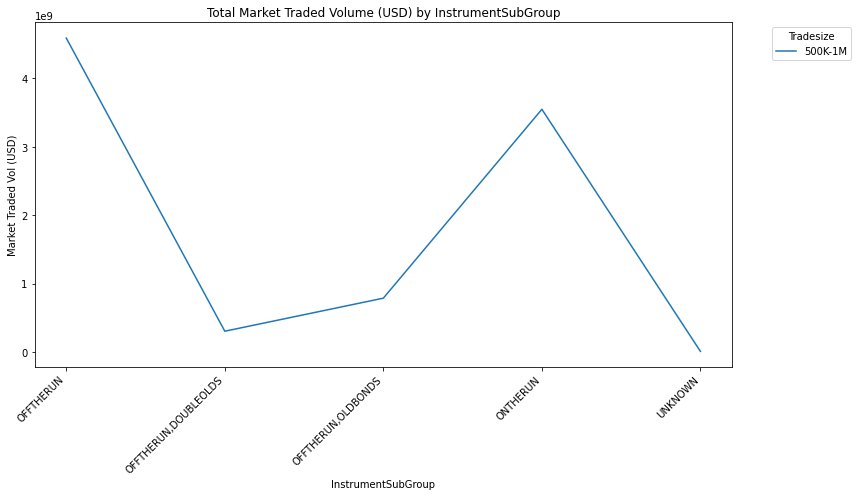

In [87]:
# 4. Market Traded Volume Analysis
market_traded_vol = df.groupby(['InstrumentSubGroup',"TradeSizeBucket"])['Market Traded Vol (USD)'].sum().unstack()

for column in market_traded_vol.columns:
    plt.figure(figsize=(12, 7))
    plt.plot(market_traded_vol.index, market_traded_vol[column], label=column)
    plt.title('Total Market Traded Volume (USD) by InstrumentSubGroup')
    plt.ylabel('Market Traded Vol (USD)')
    plt.xlabel('InstrumentSubGroup')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Tradesize', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()